In [1]:
import numpy as np
import jax
import jax.numpy as jnp
from jax import jacfwd
from jax import jit
from jax import vmap
import emcee
import h5py
import corner
import matplotlib.pyplot as plt
import corner
import VBMicrolensing
VBM = VBMicrolensing.VBMicrolensing()
import tqdm
import math
import sys
import multiprocessing
sys.path.append("/moao38_7/nunota/gapmoe/src/gapmoe/")
from gapmoe import gapmoe
import EarthMotion
import parametrics
JD0 = 2450000
from emcee.autocorr import integrated_time

import jax
import jax.numpy as jnp
from jax import jacfwd
from jax import jit
from jax import vmap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
from matplotlib.patches import Patch
import arviz as az

import logging
logging.getLogger("emcee.autocorr").setLevel(logging.ERROR)

from matplotlib.lines import Line2D

tref = 10063.874
coords = "17:57:38.03 -28:38:28.53"

VBM.t0_par = tref+JD0
VBM.parallaxsystem = 1
VBM.SetObjectCoordinates(coords)

RA_str,Dec_str = "17:57:38.03","-28:38:28.53"
RA_deg = EarthMotion.hms_string_to_degrees(RA_str)
Dec_deg = EarthMotion.dms_string_to_degrees(Dec_str)
vEarth = EarthMotion.calc_vEarth(tref,RA_deg,Dec_deg)

gapmoe_model = gapmoe(RA_deg,Dec_deg)
gapmoe_model.set_data()

In [2]:
from matplotlib import rcParams
rcParams["font.size"] = 15
rcParams["axes.linewidth"] = 3
rcParams['xtick.top'] = True
rcParams['ytick.right'] = True
rcParams['xtick.direction'] = 'in'
rcParams['ytick.direction'] = 'in'
rcParams['xtick.major.size'] = 10
rcParams['xtick.major.width'] = 1.5
rcParams['xtick.minor.size'] = 5
rcParams['xtick.minor.width'] = 1.5
rcParams['ytick.major.size'] = 10
rcParams['ytick.major.width'] = 1.5
rcParams['ytick.minor.size'] = 5
rcParams['ytick.minor.width'] = 1.5

In [14]:
def weighted_percentile(data, weights, percentiles=[16, 50, 84]):
    """Weighted percentile calculation"""
    sorter = np.argsort(data)
    data_sorted = data[sorter]
    weights_sorted = weights[sorter]
    cumsum = np.cumsum(weights_sorted)
    cumsum /= cumsum[-1]
    return np.interp(np.array(percentiles)/100, cumsum, data_sorted)

mu_rel_N  = 3.000000  # mas/yr
mu_rel_E  = 3.000000 # mas/yr
M_L      = 0.523487      # M_sun
D_L       = 3.663743      # kpc
D_S       =  8.142611       # kpc
R_orbit   =  2.999999  # AU
e   =0.500000
cos_i    = 0.620905
omega    =-1.177002
Omega    =(0.572726- np.pi)% (2*np.pi)
nu    =  -1.964761

t0_true = 10085 
u0_true = 0.01
q_true =  0.005
alpha_true =3.65*np.pi/4
tE_true = 68.5053
rho_true =8.96025e-05
s_true = 0.950001
piEN_true =0.128858
piEE_true =0.136441
gamma1_true = -0.00137559
gamma2_true = 0.00149516
gamma3_true =  -0.00188781
r_s_true = 0.000133878
a_s_true = 1.07743

truths_lc_04 = [t0_true, tE_true,u0_true, rho_true, q_true, s_true, alpha_true,
                piEN_true, piEE_true, gamma1_true, gamma2_true, gamma3_true,
                r_s_true, a_s_true]

truths_kep_04 = [M_L, D_L, D_S, mu_rel_N, mu_rel_E, R_orbit,
                 e, cos_i,  Omega,omega, nu]

In [15]:

mpl.rc('font', **{'family': 'serif', 'serif': ['Liberation Serif', 'DejaVu Serif']})
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    "font.size": 20,
    "axes.labelsize": 15,
    "axes.titlesize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.edgecolor": "0.3",
    "axes.linewidth": 1.4,
    "grid.alpha": 0.25,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

In [16]:
label_inds_kep = {"t0": 0, "tE": 1, "u0": 2, "rho": 3, "q": 4, "s": 5, "alpha": 6,
                  "piEN": 7, "piEE": 8, "gamma1": 9, "gamma2": 10, "gamma3": 11,
                  "rs": 12, "as": 13}

label_inds_kep_phys = {"ML": 3, "DL": 4, "DS": 5, "muN": 6, "muE": 7, "a": 8,
                       "e": 9, "cos_i": 10, "Omega": 11, "omega": 12, "nu": 13}

In [17]:
def read_chain(path,burnin,thin,flat=True):
    sampler = emcee.backends.HDFBackend(path)
    chain = sampler.get_chain(flat=flat, discard=burnin, thin=thin)
    blob = sampler.get_blobs(flat=flat, discard=burnin, thin=thin) 
    lnprob = sampler.get_log_prob(flat=flat, discard=burnin, thin=thin) 
    return chain, blob,lnprob

names = "wtj          M_L   D_L   D_S          t_E      theta_E         pi_E         pi_EN         pi_EE       mu_rel        mu_Sl        mu_Sb     I_L     K_L iS iL fREM".split()


def load_genulens(path):
    genulens_out = np.genfromtxt(path,names=names)
    wtj = genulens_out["wtj"] / np.sum(genulens_out["wtj"])
    ML_genu = genulens_out["M_L"]
    DL_genu = genulens_out["D_L"] * 1e-3
    DS_genu = genulens_out["D_S"] * 1e-3
    muN_genu = genulens_out["mu_rel"] * genulens_out["pi_EN"] / genulens_out["pi_E"] + genulens_out["theta_E"] * genulens_out["pi_E"]  * vEarth[0]
    muE_genu = genulens_out["mu_rel"] * genulens_out["pi_EE"] / genulens_out["pi_E"] + genulens_out["theta_E"] * genulens_out["pi_E"]  * vEarth[1]

    return np.array(wtj), np.array([ML_genu,DL_genu,DS_genu,muN_genu,muE_genu ]).T

In [18]:
kep_gap_chain,  kep_gap_phys = np.load("../test_result/array/kep_gap_chain_01.npy"), np.load("../test_result/array/kep_gap_phys_02.npy")
kep_wo_chain,  kep_wo_phys = np.load("../test_result/array/kep_wo_chain_01.npy"), np.load("../test_result/array/kep_wo_phys_02.npy")
weight_kep_01 = np.load("../test_result/array/kep_wo_wt_01.npy")

static_wo_chain = np.load("../test_result/array/static_wo_chain_01.npy")
static_wo_brob = np.load("../test_result/array/static_wo_brob_01.npy")

wtj_para_01, genuout_para_01 = load_genulens("/moao38_7/nunota/gapmoe/test_result/genout/genuout_para_02.dat")
wtj_wo_para_01, genuout_wo_para_01 = load_genulens("/moao38_7/nunota/gapmoe/test_result/genout/genuout_wo_para_02.dat")

In [19]:
ranges = [
    (-0.3, 1.8),      
    (1, 11),      
    (3, 18),     
    (-15, 15),         
    (-15, 15),         
]


def cut_genuout(genuout,wtj):
    genuout = genuout[np.where((genuout[:,0]>ranges[0][0])&(genuout[:,0]<ranges[0][1]))]
    genuout = genuout[np.where((genuout[:,1]>ranges[1][0])&(genuout[:,1]<ranges[1][1]))]
    genuout = genuout[np.where((genuout[:,2]>ranges[2][0])&(genuout[:,2]<ranges[2][1]))]
    genuout = genuout[np.where((genuout[:,3]>ranges[3][0])&(genuout[:,3]<ranges[3][1]))]
    genuout = genuout[np.where((genuout[:,4]>ranges[4][0])&(genuout[:,4]<ranges[4][1]))]
    
    wtj = wtj[np.where((genuout[:,0]>ranges[0][0])&(genuout[:,0]<ranges[0][1]))]
    wtj = wtj[np.where((genuout[:,1]>ranges[1][0])&(genuout[:,1]<ranges[1][1]))]
    wtj = wtj[np.where((genuout[:,2]>ranges[2][0])&(genuout[:,2]<ranges[2][1]))]
    wtj = wtj[np.where((genuout[:,3]>ranges[3][0])&(genuout[:,3]<ranges[3][1]))]
    wtjt = wtj[np.where((genuout[:,4]>ranges[4][0])&(genuout[:,4]<ranges[4][1]))]
    
    return genuout, wtj
    
genuout_para_01,wtj_para_01 = cut_genuout(genuout_para_01,wtj_para_01)
genuout_wo_para_01,wtj_wo_para_01 = cut_genuout(genuout_wo_para_01,wtj_wo_para_01)

In [20]:
genuout_para_01.shape

(100460, 5)

In [21]:
 kep_gap_phys[:,3:8].shape

(2957, 5)

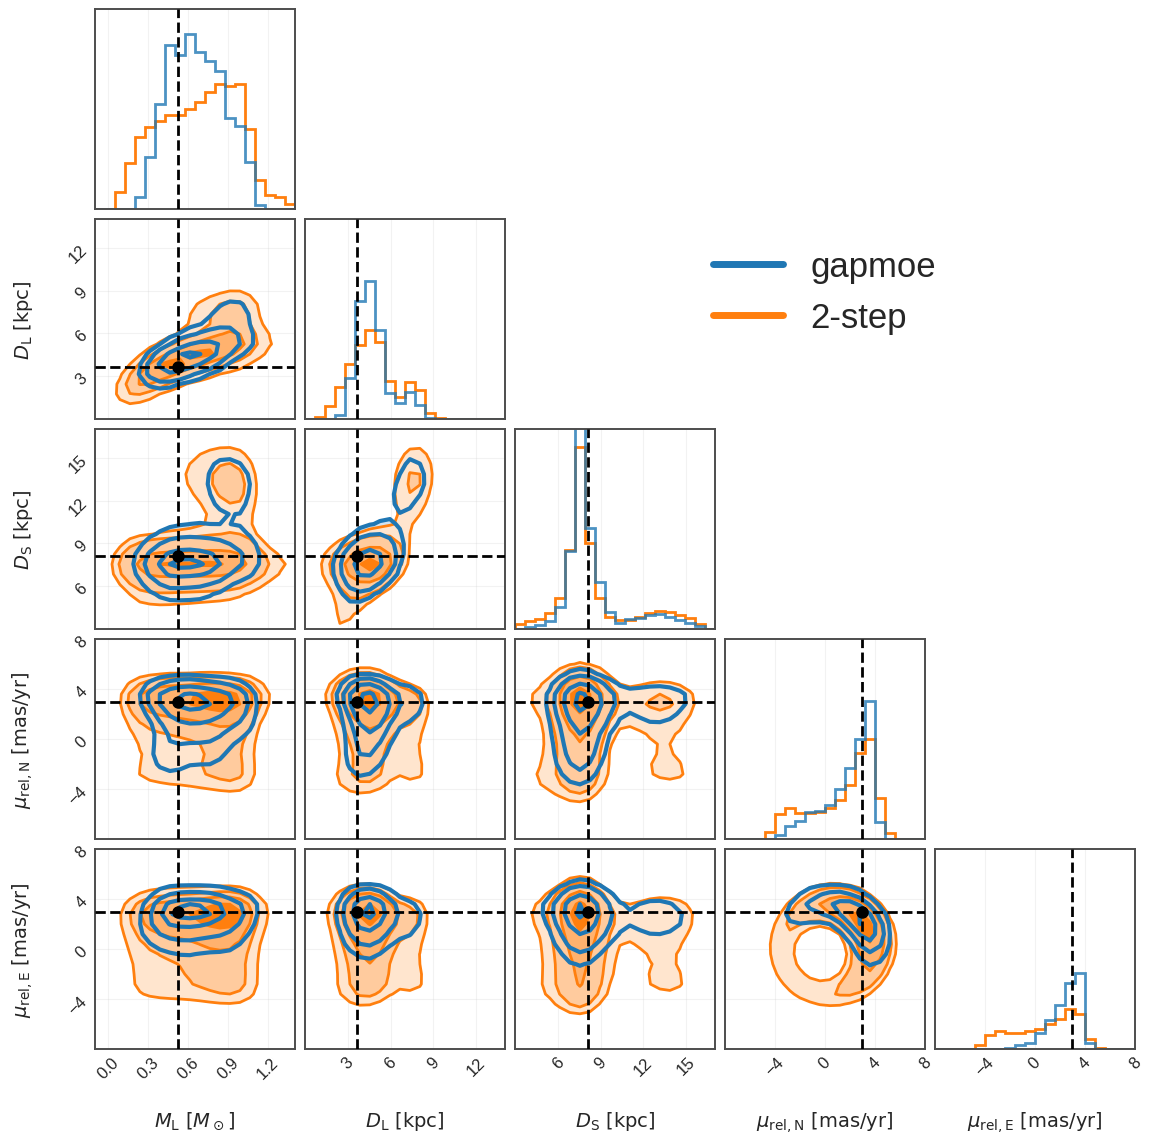

In [25]:
labels_phys = [
    r"$M_{\rm L}\ [{M_\odot}]$",
    r"$D_{\rm L}\ [{\rm kpc}]$",
    r"$D_{\rm S}\ [{\rm kpc}]$",
    r"$\mu_{\rm rel,N}\ [{\rm mas/yr}]$",
    r"$\mu_{\rm rel,E}\ [{\rm mas/yr}]$"
]

ranges = [
    (-0.1, 1.4),   
    (0, 14),       
    (3, 17),     
    (-8, 8),     
    (-8, 8), 
]
fig = corner.corner(
    kep_gap_phys[:, 3:8],
    labels=labels_phys,
    range=ranges,
    color="C0",
    hist_kwargs={"density": True, "linewidth": 2, "alpha": 0.8, "histtype": "step","zorder":2},
    label_kwargs={"fontsize": 14},
    contour_kwargs={"zorder": 5, "linewidths": 3},
    fill_contours=True,
    no_fill_contours=True,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,
    smooth=1.0,
)

corner.corner(
    genuout_wo_para_01,
    weights=wtj_wo_para_01,
    fig=fig,
    range=ranges,
    color="C1",
    hist_kwargs={"density": True, "linewidth": 2, "alpha": 1.0, "histtype": "step","zorder":1},
    label_kwargs={"fontsize": 14},
    contour_kwargs={"zorder": 3, "linewidths": 2},
    fill_contours=True,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,
    smooth=1.0,
)


ndim = kep_gap_phys[:, 3:8].shape[1]
axes = np.array(fig.axes).reshape((ndim, ndim))
for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        ax.minorticks_on()
        ax.tick_params(which="both", direction="in", top=True, right=True)

truths = truths_kep_04[:5]
for i in range(1, ndim):
    for j in range(i):
        ax = axes[i, j]
        ax.axhline(truths[i], color="k", linestyle="--", lw=2, zorder=9)
        ax.axvline(truths[j], color="k", linestyle="--", lw=2, zorder=9)
        ax.plot(truths[j], truths[i], "o", color="k", markersize=8, zorder=10)

for i in range(ndim):
    ax = axes[i, i]
    ax.axvline(truths[i], color="k", linestyle="--", lw=2, zorder=9)
    
ylims = [
    (0, 2),   # M_L
    (0, 0.6),   # D_L
    (0, 0.5),   # D_S
    (0, 0.5),   # mu_rel_N
    (0, 1),   # mu_rel_E
]

for i in range(ndim):
    ax = axes[i, i]
    ax.set_ylim(ylims[i])
    
handles = [
    Line2D([], [], color="C0", lw=5, label="gapmoe"),
    Line2D([], [], color="C1", lw=5, label="2-step"),
]
axes[1, -2].legend(handles=handles, fontsize=25, loc="upper center", frameon=False)
plt.savefig("/moao38_7/nunota/gapmoe/test_figures/simu_02_corner_kepler.pdf")
plt.show()


In [23]:

def weighted_percentile(data, weights, percentiles=[5, 95]):
    """Weighted percentile calculation"""
    sorter = np.argsort(data)
    data_sorted = data[sorter]
    weights_sorted = weights[sorter]

    cumsum = np.cumsum(weights_sorted)
    cumsum /= cumsum[-1]

    return np.interp(np.array(percentiles) / 100.0, cumsum, data_sorted)


# ========================================
#  Light-curve parameters metadata
# ========================================

# t0 の基準 (ちゃんと 10085 にしておく)
tref = 10085

params_lc = [
    dict(
        name=r"$t_0 - 10085$",
        unit=r"day",
        key="t0",
        idx=label_inds_kep["t0"],      # gap 側のインデックス
        idx_wo=label_inds_kep["t0"],   # static_wo 側のインデックス
        truth=t0_true - tref,
        scale=1.0,
        fmt="{:.3f}",
        prior_gap=r"$\mathcal{U}(10000,11000)$",
        prior_wo=r"$\mathcal{U}(10000,11000)$",
        transform=lambda x: x - tref,
    ),
    dict(
        name=r"$t_{\rm E}$",
        unit=r"day",
        key="tE",
        idx=label_inds_kep["tE"],
        idx_wo=label_inds_kep["tE"],
        truth=tE_true,
        scale=1.0,
        fmt="{:.2f}",
        prior_gap="---",
        prior_wo=r"$\mathcal{U}(0.1,1000)$",
    ),
    dict(
        name=r"$u_0$",
        unit=r"$10^{-2}$",
        key="u0",
        idx=label_inds_kep["u0"],
        idx_wo=label_inds_kep["u0"],
        truth=u0_true,
        scale=1e2,
        fmt="{:.2f}",
        prior_gap=r"$\mathcal{U}(-5,5)$",
        prior_wo=r"$\mathcal{U}(-5,5)$",
    ),
    dict(
        name=r"$\rho$",
        unit=r"$10^{-3}$",
        key="rho",
        idx=label_inds_kep["rho"],
        idx_wo=label_inds_kep["rho"],
        truth=rho_true,
        scale=1e3,
        fmt="{:.2f}",
        prior_gap="---",
        prior_wo=r"$\mathcal{U}(0,1)$",
    ),
    dict(
        name=r"$q$",
        unit=r"$10^{-2}$",
        key="q",
        idx=label_inds_kep["q"],
        idx_wo=label_inds_kep["q"],
        truth=q_true,
        scale=1e2,
        fmt="{:.2f}",
        prior_gap=r"\text{log}~$\mathcal{U}(10^{-5},1)$",
        prior_wo=r"\text{log}~$\mathcal{U}(10^{-5},1)$",
    ),
    dict(
        name=r"$s$",
        unit=r"---",
        key="s",
        idx=label_inds_kep["s"],
        idx_wo=label_inds_kep["s"],
        truth=s_true,
        scale=1.0,
        fmt="{:.3f}",
        prior_gap="---",
        prior_wo=r"$\mathcal{U}(0,5)$",
    ),
    dict(
        name=r"$\alpha$",
        unit=r"rad",
        key="alpha",
        idx=label_inds_kep["alpha"],
        idx_wo=label_inds_kep["alpha"],
        truth=alpha_true,
        scale=1.0,
        fmt="{:.3f}",
        prior_gap="---",
        prior_wo=r"$\mathcal{U}(-\pi,\pi)$",
    ),
    dict(
        name=r"$\pi_{\rm E,N}$",
        unit=r"$10^{-1}$",
        key="piEN",
        idx=label_inds_kep["piEN"],
        idx_wo=None,  # static_wo には入っていないので None → No-gap 列は --- にする
        truth=piEN_true,
        scale=10.0,
        fmt="{:.2f}",
        prior_gap="---",
        prior_wo=r"$\mathcal{U}(-3,3)$",
    ),
    dict(
        name=r"$\pi_{\rm E,E}$",
        unit=r"$10^{-1}$",
        key="piEE",
        idx=label_inds_kep["piEE"],
        idx_wo=None,  # ここも static_wo には無い
        truth=piEE_true,
        scale=10.0,
        fmt="{:.2f}",
        prior_gap="---",
        prior_wo=r"$\mathcal{U}(-3,3)$",
    ),
    dict(
        name=r"$\gamma_1$",
        unit=r"$10^{-3}~{\rm day}^{-1}$",
        key="gamma1",
        idx=label_inds_kep["gamma1"],
        idx_wo=None,
        truth=gamma1_true,
        scale=1e3,
        fmt="{:.2f}",
        prior_gap="---",
        prior_wo=r"$\mathcal{U}(-1,1)$",
    ),
    dict(
        name=r"$\gamma_2$",
        unit=r"$10^{-3}~{\rm day}^{-1}$",
        key="gamma2",
        idx=label_inds_kep["gamma2"],
        idx_wo=None,
        truth=gamma2_true,
        scale=1e3,
        fmt="{:.2f}",
        prior_gap="---",
        prior_wo=r"$\mathcal{U}(-1,1)$",
    ),
    dict(
        name=r"$\gamma_3$",
        unit=r"$10^{-3}~{\rm day}^{-1}$",
        key="gamma3",
        idx=label_inds_kep["gamma3"],
        idx_wo=None,
        truth=gamma3_true,
        scale=1e3,
        fmt="{:.2f}",
        prior_gap="---",
        prior_wo=r"$\mathcal{U}(-1,1)$",
    ),
    dict(
        name=r"$r_s$",
        unit=r"---",
        key="rs",
        idx=label_inds_kep["rs"],
        idx_wo=None,
        truth=r_s_true,
        scale=1.0,
        fmt="{:.2f}",
        prior_gap="---",
        prior_wo=r"$\mathcal{U}(-10,10)$",
    ),
    dict(
        name=r"$a_s$",
        unit=r"---",
        key="as",
        idx=label_inds_kep["as"],
        idx_wo=None,
        truth=a_s_true,
        scale=1.0,
        fmt="{:.2f}",
        prior_gap="---",
        prior_wo=r"$\mathcal{U}(0,10)$",
    ),
]


def get_samples_lc(param, model="gap"):
    """LC パラメータ用：gap / static-wo からサンプルを取り出す"""
    if model == "gap":
        arr = kep_gap_chain
        col = param["idx"]

    elif model == "wo":
        # static_wo_chain を使う
        # piEN, piEE は idx_wo=None なので None のときはサンプル無し
        idx_wo = param.get("idx_wo", param["idx"])
        if idx_wo is None:
            return None
        arr = static_wo_chain
        col = idx_wo

    else:
        raise ValueError("model must be 'gap' or 'wo'")

    vals = arr[:, col]

    if param.get("transform") is not None:
        vals = param["transform"](vals)

    return vals


def format_interval_lc(param, model="gap"):
    """5–95% の区間を LaTeX 形式に整形（LC 用）"""
    vals = get_samples_lc(param, model=model)

    # static_wo に存在しないパラメータ (piEN, piEE) 用
    if vals is None:
        return r"\text{---}"

    p5, p95 = np.percentile(vals, [5, 95])
    p5 *= param["scale"]
    p95 *= param["scale"]

    return param["fmt"].format(p5) + r"\,\text{--}\," + param["fmt"].format(p95)


def format_truth_lc(param):
    val = param["truth"] * param["scale"]
    return param["fmt"].format(val)


# ========================================
#  Physical parameters metadata (genuout wo)
# ========================================

params_phys = [
    dict(
        name=r"$M_{\rm L}$",
        unit=r"$M_\odot$",
        idx_gap=label_inds_kep_phys["ML"],
        idx_gen=0,
        truth=M_L,
        scale=1.0,
        fmt="{:.2f}",
        prior_gap="Galactic model",
        prior_wo="---",
    ),
    dict(
        name=r"$D_{\rm L}$",
        unit=r"kpc",
        idx_gap=label_inds_kep_phys["DL"],
        idx_gen=1,
        truth=D_L,
        scale=1.0,
        fmt="{:.2f}",
        prior_gap="Galactic model",
        prior_wo="---",
    ),
    dict(
        name=r"$D_{\rm S}$",
        unit=r"kpc",
        idx_gap=label_inds_kep_phys["DS"],
        idx_gen=2,
        truth=D_S,
        scale=1.0,
        fmt="{:.2f}",
        prior_gap="Galactic model",
        prior_wo="---",
    ),
    dict(
        name=r"$\mu_{\rm rel,N}$",
        unit=r"mas/yr",
        idx_gap=label_inds_kep_phys["muN"],
        idx_gen=3,
        truth=mu_rel_N,
        scale=1.0,
        fmt="{:.2f}",
        prior_gap="Galactic model",
        prior_wo="---",
    ),
    dict(
        name=r"$\mu_{\rm rel,E}$",
        unit=r"mas/yr",
        idx_gap=label_inds_kep_phys["muE"],
        idx_gen=4,
        truth=mu_rel_E,
        scale=1.0,
        fmt="{:.2f}",
        prior_gap="Galactic model",
        prior_wo="---",
    ),
    dict(
        name=r"$a$",
        unit=r"AU",
        idx_gap=label_inds_kep_phys["a"],
        idx_gen=None,  # genout にはないので ---
        truth=R_orbit,
        scale=1.0,
        fmt="{:.2f}",
        prior_gap=r"\text{log}~$\mathcal{U}(10^{-1},10^{4})$",
        prior_wo="---",
    ),
    dict(
        name=r"$e$",
        unit=r"---",
        idx_gap=label_inds_kep_phys["e"],
        idx_gen=None,
        truth=e,
        scale=1.0,
        fmt="{:.2f}",
        prior_gap=r"$\mathcal{U}(0,1)$",
        prior_wo="---",
    ),
    dict(
        name=r"$\cos{i}$",
        unit=r"---",
        idx_gap=label_inds_kep_phys["cos_i"],
        idx_gen=None,
        truth=cos_i,
        scale=1.0,
        fmt="{:.2f}",
        prior_gap=r"$\mathcal{U}(-1,1)$",
        prior_wo="---",
    ),
    dict(
        name=r"$\omega$",
        unit=r"rad",
        idx_gap=label_inds_kep_phys["omega"],
        idx_gen=None,
        truth=omega,
        scale=1.0,
        fmt="{:.2f}",
        prior_gap=r"$\mathcal{U}(-\pi,\pi)$",
        prior_wo="---",
    ),
    dict(
        name=r"$\Omega_{\rm NE}$",
        unit=r"rad",
        idx_gap=label_inds_kep_phys["Omega"],
        idx_gen=None,
        truth=Omega,
        scale=1.0,
        fmt="{:.2f}",
        prior_gap=r"$\mathcal{U}(-\pi,\pi)$",
        prior_wo="---",
    ),
    dict(
        name=r"$\nu$",
        unit=r"rad",
        idx_gap=label_inds_kep_phys["nu"],
        idx_gen=None,
        truth=nu,
        scale=1.0,
        fmt="{:.2f}",
        prior_gap=r"$\mathcal{U}(-\pi,\pi)$",
        prior_wo="---",
    ),
]


def format_interval_phys(param, model="gap"):
    """5–95% の区間を LaTeX 形式に整形（Physical 用）"""
    if model == "gap":
        vals = kep_gap_phys[:, param["idx_gap"]]
        p5, p95 = np.percentile(vals, [5, 95])

    elif model == "wo":
        # genout に無いパラメータは ---
        if param.get("idx_gen") is None:
            return r"\text{---}"
        vals = genuout_wo_para_01[:, param["idx_gen"]]
        p5, p95 = weighted_percentile(vals, wtj_wo_para_01, [5, 95])

    else:
        raise ValueError("model must be 'gap' or 'wo'")

    p5 *= param["scale"]
    p95 *= param["scale"]

    return param["fmt"].format(p5) + r"\,\text{--}\," + param["fmt"].format(p95)


def format_truth_phys(param):
    val = param["truth"] * param["scale"]
    return param["fmt"].format(val)


# ========================================
#  LaTeX (deluxetable*) の本体生成
# ========================================

lines = []
lines.append(r"\begin{deluxetable*}{cccccc|c}")
lines.append(
    r"\tablecaption{Summary statistics for Event~1 with gap and no-gap models: "
    r"central 90\% intervals (p5--p95), true values, and prior distributions"
    r"\label{table:event1_gap_wo}}"
)
lines.append(
    r"\tablehead{"
    r"  \colhead{Parameter} &"
    r"  \colhead{Unit} &"
    r"  \colhead{Gap 90\% interval} &"
    r"  \colhead{No-gap 90\% interval} &"
    r"  \colhead{True} &"
    r"  \colhead{$\pi_\gal$} &"
    r"  \colhead{$\pi_1$}"
    r"}"
)
lines.append(r"\startdata")

# ---- Light-curve block ----
lines.append(r"\cutinhead{Light-curve parameters}")

for p in params_lc:
    gap_int = format_interval_lc(p, model="gap")
    wo_int = format_interval_lc(p, model="wo")
    truth_str = format_truth_lc(p)

    line = (
        f"{p['name']} & {p['unit']} & " 
        f"${gap_int}$ & "
        f"${wo_int}$ & "
        f"${truth_str}$ & "
        f"{p['prior_gap']} & {p['prior_wo']} \\\\"
    )
    lines.append(line)

# ---- Physical block ----
lines.append(r"\cutinhead{Physical parameters}")

for p in params_phys:
    gap_int = format_interval_phys(p, model="gap")
    wo_int = format_interval_phys(p, model="wo")
    truth_str = format_truth_phys(p)

    line = (
        f"{p['name']} & {p['unit']} & "
        f"${gap_int}$ & "
        f"${wo_int}$ & "
        f"${truth_str}$ & "
        f"{p['prior_gap']} & {p['prior_wo']} \\\\"
    )
    lines.append(line)

lines.append(r"\enddata")
lines.append(r"\end{deluxetable*}")

# 出力
for ln in lines:
    print(ln)


\begin{deluxetable*}{cccccc|c}
\tablecaption{Summary statistics for Event~1 with gap and no-gap models: central 90\% intervals (p5--p95), true values, and prior distributions\label{table:event1_gap_wo}}
\tablehead{  \colhead{Parameter} &  \colhead{Unit} &  \colhead{Gap 90\% interval} &  \colhead{No-gap 90\% interval} &  \colhead{True} &  \colhead{$\pi_\gal$} &  \colhead{$\pi_1$}}
\startdata
\cutinhead{Light-curve parameters}
$t_0 - 10085$ & day & $0.003\,\text{--}\,0.019$ & $0.000\,\text{--}\,0.021$ & $0.000$ & $\mathcal{U}(10000,11000)$ & $\mathcal{U}(10000,11000)$ \\
$t_{\rm E}$ & day & $57.22\,\text{--}\,59.38$ & $57.24\,\text{--}\,59.46$ & $68.51$ & --- & $\mathcal{U}(0.1,1000)$ \\
$u_0$ & $10^{-2}$ & $0.98\,\text{--}\,1.03$ & $0.97\,\text{--}\,1.03$ & $1.00$ & $\mathcal{U}(-5,5)$ & $\mathcal{U}(-5,5)$ \\
$\rho$ & $10^{-3}$ & $0.56\,\text{--}\,0.62$ & $0.56\,\text{--}\,0.74$ & $0.09$ & --- & $\mathcal{U}(0,1)$ \\
$q$ & $10^{-2}$ & $0.09\,\text{--}\,0.11$ & $0.09\,\text{--}\,0.12$ &

In [24]:
def weighted_percentile(data, weights, percentiles=[5, 95]):
    """Weighted percentile calculation"""
    sorter = np.argsort(data)
    data_sorted = data[sorter]
    weights_sorted = weights[sorter]

    cumsum = np.cumsum(weights_sorted)
    cumsum /= cumsum[-1]

    return np.interp(np.array(percentiles) / 100.0, cumsum, data_sorted)


# ========================================
#  Light-curve parameters metadata
# ========================================

# t0 の基準 (ちゃんと 10085 にしておく)
tref = 10085

params_lc = [
    dict(
        name=r"$t_0 - 10085$",
        unit=r"day",
        key="t0",
        idx=label_inds_kep["t0"],      # gap 側のインデックス
        idx_wo=label_inds_kep["t0"],   # static_wo 側のインデックス
        truth=t0_true - tref,
        scale=1.0,
        fmt="{:.3f}",
        prior_gap=r"$\mathcal{U}(10000,11000)$",
        prior_wo=r"$\mathcal{U}(10000,11000)$",
        transform=lambda x: x - tref,
    ),
    dict(
        name=r"$t_{\rm E}$",
        unit=r"day",
        key="tE",
        idx=label_inds_kep["tE"],
        idx_wo=label_inds_kep["tE"],
        truth=tE_true,
        scale=1.0,
        fmt="{:.2f}",
        prior_gap="---",
        prior_wo=r"$\mathcal{U}(0.1,1000)$",
    ),
    dict(
        name=r"$u_0$",
        unit=r"$10^{-2}$",
        key="u0",
        idx=label_inds_kep["u0"],
        idx_wo=label_inds_kep["u0"],
        truth=u0_true,
        scale=1e2,
        fmt="{:.2f}",
        prior_gap=r"$\mathcal{U}(-5,5)$",
        prior_wo=r"$\mathcal{U}(-5,5)$",
    ),
    dict(
        name=r"$\rho$",
        unit=r"$10^{-3}$",
        key="rho",
        idx=label_inds_kep["rho"],
        idx_wo=label_inds_kep["rho"],
        truth=rho_true,
        scale=1e3,
        fmt="{:.2f}",
        prior_gap="---",
        prior_wo=r"$\mathcal{U}(0,1)$",
    ),
    dict(
        name=r"$q$",
        unit=r"$10^{-2}$",
        key="q",
        idx=label_inds_kep["q"],
        idx_wo=label_inds_kep["q"],
        truth=q_true,
        scale=1e2,
        fmt="{:.2f}",
        prior_gap=r"\text{log}~$\mathcal{U}(10^{-5},1)$",
        prior_wo=r"\text{log}~$\mathcal{U}(10^{-5},1)$",
    ),
    dict(
        name=r"$s$",
        unit=r"---",
        key="s",
        idx=label_inds_kep["s"],
        idx_wo=label_inds_kep["s"],
        truth=s_true,
        scale=1.0,
        fmt="{:.3f}",
        prior_gap="---",
        prior_wo=r"$\mathcal{U}(0,5)$",
    ),
    dict(
        name=r"$\alpha$",
        unit=r"rad",
        key="alpha",
        idx=label_inds_kep["alpha"],
        idx_wo=label_inds_kep["alpha"],
        truth=alpha_true,
        scale=1.0,
        fmt="{:.3f}",
        prior_gap="---",
        prior_wo=r"$\mathcal{U}(-\pi,\pi)$",
    ),
    dict(
        name=r"$\pi_{\rm E,N}$",
        unit=r"$10^{-1}$",
        key="piEN",
        idx=label_inds_kep["piEN"],
        idx_wo=None,  # static_wo には入っていないので None → No-gap 列は --- にする
        truth=piEN_true,
        scale=10.0,
        fmt="{:.2f}",
        prior_gap="---",
        prior_wo=r"---",
    ),
    dict(
        name=r"$\pi_{\rm E,E}$",
        unit=r"$10^{-1}$",
        key="piEE",
        idx=label_inds_kep["piEE"],
        idx_wo=None,  # ここも static_wo には無い
        truth=piEE_true,
        scale=10.0,
        fmt="{:.2f}",
        prior_gap="---",
        prior_wo=r"---",
    ),
    dict(
        name=r"$\gamma_1$",
        unit=r"$10^{-3}~{\rm day}^{-1}$",
        key="gamma1",
        idx=label_inds_kep["gamma1"],
        idx_wo=None,
        truth=gamma1_true,
        scale=1e3,
        fmt="{:.2f}",
        prior_gap="---",
        prior_wo=r"---",
    ),
    dict(
        name=r"$\gamma_2$",
        unit=r"$10^{-3}~{\rm day}^{-1}$",
        key="gamma2",
        idx=label_inds_kep["gamma2"],
        idx_wo=None,
        truth=gamma2_true,
        scale=1e3,
        fmt="{:.2f}",
        prior_gap="---",
        prior_wo=r"---",
    ),
    dict(
        name=r"$\gamma_3$",
        unit=r"$10^{-3}~{\rm day}^{-1}$",
        key="gamma3",
        idx=label_inds_kep["gamma3"],
        idx_wo=None,
        truth=gamma3_true,
        scale=1e3,
        fmt="{:.2f}",
        prior_gap="---",
        prior_wo=r"---",
    ),
    dict(
        name=r"$r_s$",
        unit=r"---",
        key="rs",
        idx=label_inds_kep["rs"],
        idx_wo=None,
        truth=r_s_true,
        scale=1.0,
        fmt="{:.2f}",
        prior_gap="---",
        prior_wo=r"---",
    ),
    dict(
        name=r"$a_s$",
        unit=r"---",
        key="as",
        idx=label_inds_kep["as"],
        idx_wo=None,
        truth=a_s_true,
        scale=1.0,
        fmt="{:.2f}",
        prior_gap="---",
        prior_wo=r"---",
    ),
]


def get_samples_lc(param, model="gap"):
    """LC パラメータ用：gap / static-wo からサンプルを取り出す"""
    if model == "gap":
        arr = kep_gap_chain
        col = param["idx"]

    elif model == "wo":
        # static_wo_chain を使う
        # piEN, piEE は idx_wo=None なので None のときはサンプル無し
        idx_wo = param.get("idx_wo", param["idx"])
        if idx_wo is None:
            return None
        arr = static_wo_chain
        col = idx_wo

    else:
        raise ValueError("model must be 'gap' or 'wo'")

    vals = arr[:, col]

    if param.get("transform") is not None:
        vals = param["transform"](vals)

    return vals


def format_interval_lc(param, model="gap"):
    """5–95% の区間を LaTeX 形式に整形（LC 用）"""
    vals = get_samples_lc(param, model=model)

    # static_wo に存在しないパラメータ (piEN, piEE など) 用
    if vals is None:
        return r"\text{---}"

    p5, p95 = np.percentile(vals, [5, 95])
    p5 *= param["scale"]
    p95 *= param["scale"]

    return param["fmt"].format(p5) + r"\,\text{--}\," + param["fmt"].format(p95)


def format_truth_lc(param):
    val = param["truth"] * param["scale"]
    return param["fmt"].format(val)


# ========================================
#  Physical parameters metadata (genuout wo)
# ========================================

params_phys = [
    dict(
        name=r"$M_{\rm L}$",
        unit=r"$M_\odot$",
        idx_gap=label_inds_kep_phys["ML"],
        idx_gen=0,
        truth=M_L,
        scale=1.0,
        fmt="{:.2f}",
        prior_gap="Galactic model",
        prior_wo="Galactic model",
    ),
    dict(
        name=r"$D_{\rm L}$",
        unit=r"kpc",
        idx_gap=label_inds_kep_phys["DL"],
        idx_gen=1,
        truth=D_L,
        scale=1.0,
        fmt="{:.2f}",
        prior_gap="Galactic model",
        prior_wo="Galactic model",
    ),
    dict(
        name=r"$D_{\rm S}$",
        unit=r"kpc",
        idx_gap=label_inds_kep_phys["DS"],
        idx_gen=2,
        truth=D_S,
        scale=1.0,
        fmt="{:.2f}",
        prior_gap="Galactic model",
        prior_wo="Galactic model",
    ),
    dict(
        name=r"$\mu_{\rm rel,N}$",
        unit=r"mas/yr",
        idx_gap=label_inds_kep_phys["muN"],
        idx_gen=3,
        truth=mu_rel_N,
        scale=1.0,
        fmt="{:.2f}",
        prior_gap="Galactic model",
        prior_wo="Galactic model",
    ),
    dict(
        name=r"$\mu_{\rm rel,E}$",
        unit=r"mas/yr",
        idx_gap=label_inds_kep_phys["muE"],
        idx_gen=4,
        truth=mu_rel_E,
        scale=1.0,
        fmt="{:.2f}",
        prior_gap="Galactic model",
        prior_wo="Galactic model",
    ),
    dict(
        name=r"$a$",
        unit=r"AU",
        idx_gap=label_inds_kep_phys["a"],
        idx_gen=None,  # genout にはないので ---
        truth=R_orbit,
        scale=1.0,
        fmt="{:.2f}",
        prior_gap=r"\text{log}~$\mathcal{U}(10^{-1},10^{4})$",
        prior_wo="---",
    ),
    dict(
        name=r"$e$",
        unit=r"---",
        idx_gap=label_inds_kep_phys["e"],
        idx_gen=None,
        truth=e,
        scale=1.0,
        fmt="{:.2f}",
        prior_gap=r"$\mathcal{U}(0,1)$",
        prior_wo="---",
    ),
    dict(
        name=r"$\cos{i}$",
        unit=r"---",
        idx_gap=label_inds_kep_phys["cos_i"],
        idx_gen=None,
        truth=cos_i,
        scale=1.0,
        fmt="{:.2f}",
        prior_gap=r"$\mathcal{U}(-1,1)$",
        prior_wo="---",
    ),
    dict(
        name=r"$\omega$",
        unit=r"rad",
        idx_gap=label_inds_kep_phys["omega"],
        idx_gen=None,
        truth=omega,
        scale=1.0,
        fmt="{:.2f}",
        prior_gap=r"$\mathcal{U}(-\pi,\pi)$",
        prior_wo="---",
    ),
    dict(
        name=r"$\Omega_{\rm NE}$",
        unit=r"rad",
        idx_gap=label_inds_kep_phys["Omega"],
        idx_gen=None,
        truth=Omega,
        scale=1.0,
        fmt="{:.2f}",
        prior_gap=r"$\mathcal{U}(-\pi,\pi)$",
        prior_wo="---",
    ),
    dict(
        name=r"$\nu$",
        unit=r"rad",
        idx_gap=label_inds_kep_phys["nu"],
        idx_gen=None,
        truth=nu,
        scale=1.0,
        fmt="{:.2f}",
        prior_gap=r"$\mathcal{U}(-\pi,\pi)$",
        prior_wo="---",
    ),
]


def format_interval_phys(param, model="gap"):
    """5–95% の区間を LaTeX 形式に整形（Physical 用）"""
    if model == "gap":
        vals = kep_gap_phys[:, param["idx_gap"]]
        p5, p95 = np.percentile(vals, [5, 95])

    elif model == "wo":
        # genout に無いパラメータは ---
        if param.get("idx_gen") is None:
            return r"\text{---}"
        vals = genuout_wo_para_01[:, param["idx_gen"]]
        p5, p95 = weighted_percentile(vals, wtj_wo_para_01, [5, 95])

    else:
        raise ValueError("model must be 'gap' or 'wo'")

    p5 *= param["scale"]
    p95 *= param["scale"]

    return param["fmt"].format(p5) + r"\,\text{--}\," + param["fmt"].format(p95)


def format_truth_phys(param):
    val = param["truth"] * param["scale"]
    return param["fmt"].format(val)


# ========================================
#  LaTeX (deluxetable*) の本体生成
# ========================================

lines = []
# 7 列: Param, Unit, Gap 結果, Gap prior, No-gap 結果, No-gap prior, True
lines.append(r"\begin{deluxetable*}{cc|cc|cc|c}")
lines.append(
    r"\tablecaption{Summary statistics for simulated event with gapmoe method and 2-step method: "
    r"central 90\% intervals (p5--p95), true values, and prior distributions"
    r"\label{table:event1_gap_wo}}"
)
lines.append(
    r"\tablehead{"
    r"  \colhead{Parameter} &"
    r"  \colhead{Unit} &"
    r"  \colhead{\texttt{gapmoe} method} &"
    r"  \colhead{Prior} &"
    r"  \colhead{2-step method} &"
    r"  \colhead{Prior} &"
    r"  \colhead{True}"
    r"}"
)
lines.append(r"\startdata")

# ---- Light-curve block ----
lines.append(r"\cutinhead{Light-curve parameters}")

for p in params_lc:
    gap_int = format_interval_lc(p, model="gap")
    wo_int = format_interval_lc(p, model="wo")
    truth_str = format_truth_lc(p)

    # 結果 → prior → 結果 → prior → 真値
    line = (
        f"{p['name']} & {p['unit']} & "
        f"${gap_int}$ & {p['prior_gap']} & "
        f"${wo_int}$ & {p['prior_wo']} & "
        f"${truth_str}$ \\\\"
    )
    lines.append(line)

# ---- Physical block ----
lines.append(r"\cutinhead{Physical parameters}")

for p in params_phys:
    gap_int = format_interval_phys(p, model="gap")
    wo_int = format_interval_phys(p, model="wo")
    truth_str = format_truth_phys(p)

    line = (
        f"{p['name']} & {p['unit']} & "
        f"${gap_int}$ & {p['prior_gap']} & "
        f"${wo_int}$ & {p['prior_wo']} & "
        f"${truth_str}$ \\\\"
    )
    lines.append(line)

lines.append(r"\enddata")
lines.append(r"\end{deluxetable*}")

for ln in lines:
    print(ln)


\begin{deluxetable*}{cc|cc|cc|c}
\tablecaption{Summary statistics for simulated event with gapmoe method and 2-step method: central 90\% intervals (p5--p95), true values, and prior distributions\label{table:event1_gap_wo}}
\tablehead{  \colhead{Parameter} &  \colhead{Unit} &  \colhead{\texttt{gapmoe} method} &  \colhead{Prior} &  \colhead{2-step method} &  \colhead{Prior} &  \colhead{True}}
\startdata
\cutinhead{Light-curve parameters}
$t_0 - 10085$ & day & $0.003\,\text{--}\,0.019$ & $\mathcal{U}(10000,11000)$ & $0.000\,\text{--}\,0.021$ & $\mathcal{U}(10000,11000)$ & $0.000$ \\
$t_{\rm E}$ & day & $57.22\,\text{--}\,59.38$ & --- & $57.24\,\text{--}\,59.46$ & $\mathcal{U}(0.1,1000)$ & $68.51$ \\
$u_0$ & $10^{-2}$ & $0.98\,\text{--}\,1.03$ & $\mathcal{U}(-5,5)$ & $0.97\,\text{--}\,1.03$ & $\mathcal{U}(-5,5)$ & $1.00$ \\
$\rho$ & $10^{-3}$ & $0.56\,\text{--}\,0.62$ & --- & $0.56\,\text{--}\,0.74$ & $\mathcal{U}(0,1)$ & $0.09$ \\
$q$ & $10^{-2}$ & $0.09\,\text{--}\,0.11$ & \text{log}~$\m